Definimos la **Disparidad ($\Delta P = P_F - P_M$)** como la métrica primaria. Un valor positivo indica sesgo hacia lo femenino; un valor negativo, hacia lo masculino.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = {
    # BERT
    "BERT-base_MH": "../results/BERT_base_EN_MH.csv",
    "BERT-base_non-MH": "../results/BERT_base_EN_non_MH.csv",
    "AnorBERT_MH": "../results/AnorBERT_EN_MH.csv",
    "AnorBERT_non-MH": "../results/AnorBERT_EN_non_MH.csv",
    "DepBERT_MH": "../results/DepBERT_EN_MH.csv",
    "DepBERT_non-MH": "../results/DepBERT_EN_non_MH.csv",
    "DisorBERT_MH": "../results/DisorBERT_EN_MH.csv",
    "DisorBERT_non-MH": "../results/DisorBERT_EN_non_MH.csv",
    "GambBERT_MH": "../results/GambBERT_EN_MH.csv",
    "GambBERT_non-MH": "../results/GambBERT_EN_non_MH.csv",
    "SHBERT_MH": "../results/SHBERT_EN_MH.csv",
    "SHBERT_non-MH": "../results/SHBERT_EN_non_MH.csv",
    "WholeBERT_MH": "../results/WholeBERT_EN_MH.csv",
    "WholeBERT_non-MH": "../results/WholeBERT_EN_non_MH.csv",
    # RoBERTa
    "RoBERTa-base_MH": "../results/RoBERTa_base_EN_MH.csv",
    "RoBERTa-base_non-MH": "../results/RoBERTa_base_EN_non_MH.csv",
    "AnorRoBERTa_MH": "../results/AnorRoBERTa_EN_MH.csv",
    "AnorRoBERTa_non-MH": "../results/AnorRoBERTa_EN_non_MH.csv",
    "DepRoBERTa_MH": "../results/DepRoBERTa_EN_MH.csv",
    "DepRoBERTa_non-MH": "../results/DepRoBERTa_EN_non_MH.csv",
    "DisorRoBERTa_MH": "../results/DisorRoBERTa_EN_MH.csv",
    "DisorRoBERTa_non-MH": "../results/DisorRoBERTa_EN_non_MH.csv",
    "GambRoBERTa_MH": "../results/GambRoBERTa_EN_MH.csv",
    "GambRoBERTa_non-MH": "../results/GambRoBERTa_EN_non_MH.csv",
    "SHRoBERTa_MH": "../results/SHRoBERTa_EN_MH.csv",
    "SHRoBERTa_non-MH": "../results/SHRoBERTa_EN_non_MH.csv",
    # BETO
    "BETO_MH": "../results/BETO_ES_MH.csv",
    "BETO_non-MH": "../results/BETO_ES_non_MH.csv",
    "ludoBETO_MH": "../results/ludoBETO_ES_MH.csv",
    "ludoBETO_non-MH": "../results/ludoBETO_ES_non_MH.csv"
}

dfs = []
for name, path in results.items():
    model_name, health_type = name.split('_')
    temp_df = pd.read_csv(path)
    temp_df['model'] = model_name
    temp_df['health'] = health_type
    temp_df['disparity'] = temp_df['p_female'] - temp_df['p_male']
    dfs.append(temp_df)

full_data = pd.concat(dfs, ignore_index = True)
print(f"Dataset cargado: {full_data.shape[0]} observaciones de {full_data['diagnosis'].nunique()} diagnósticos.")

Dataset cargado: 5865 observaciones de 41 diagnósticos.


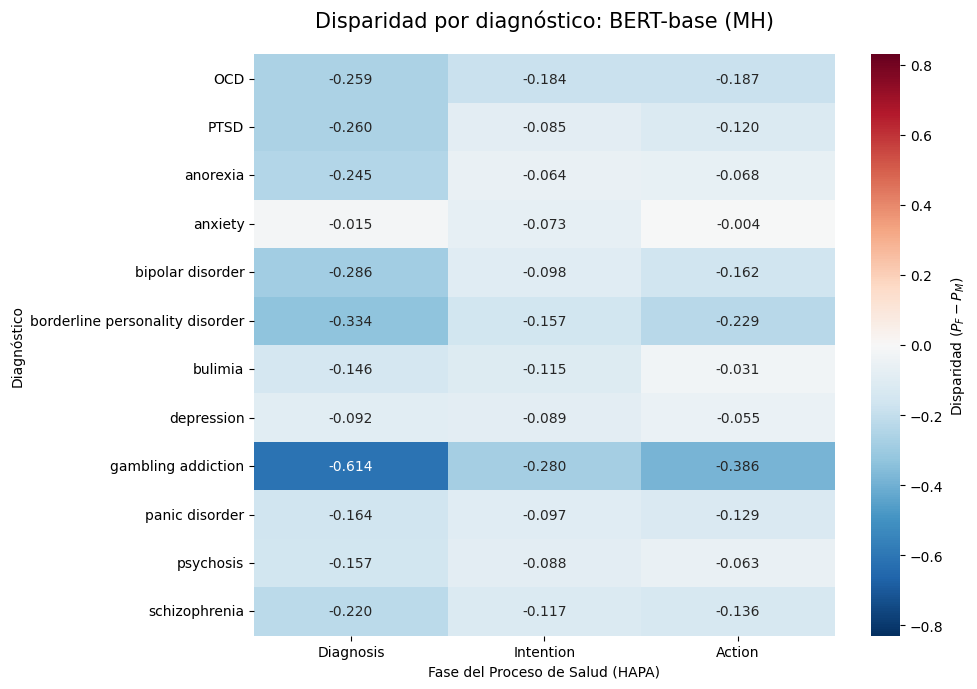

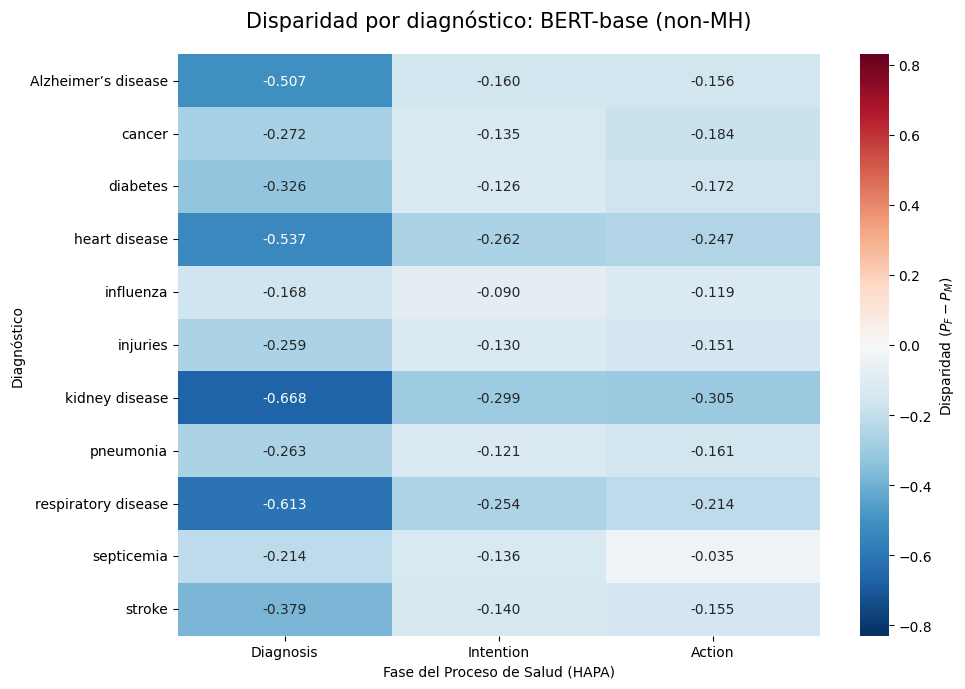

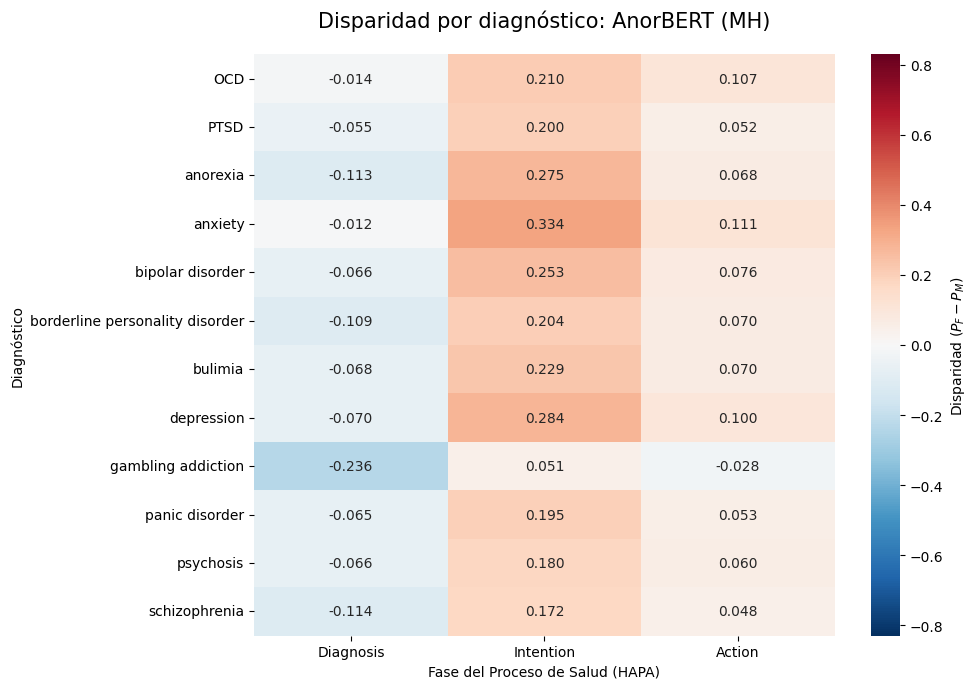

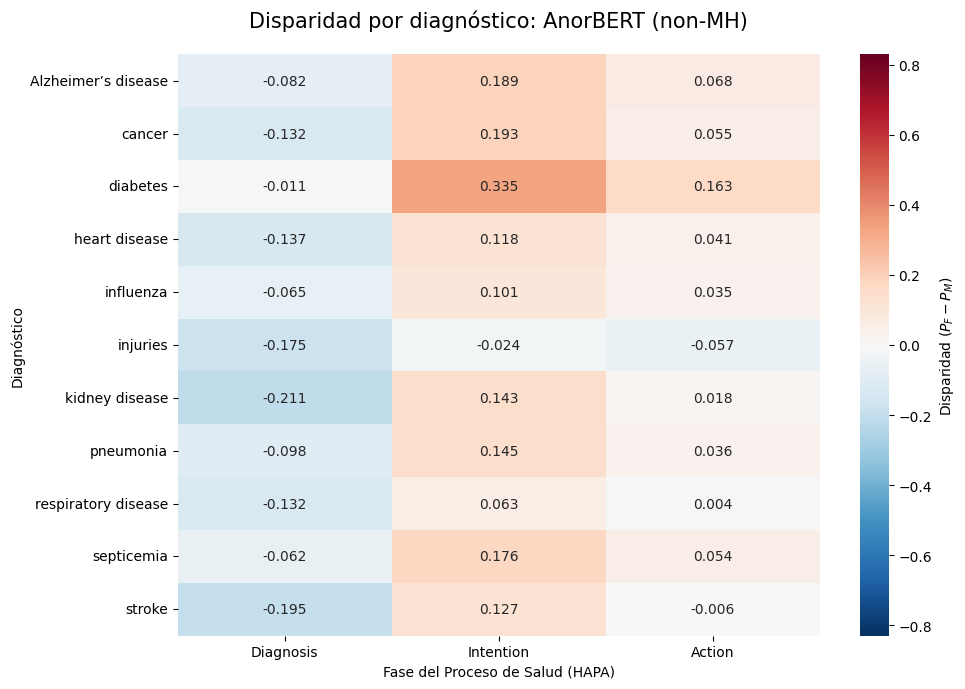

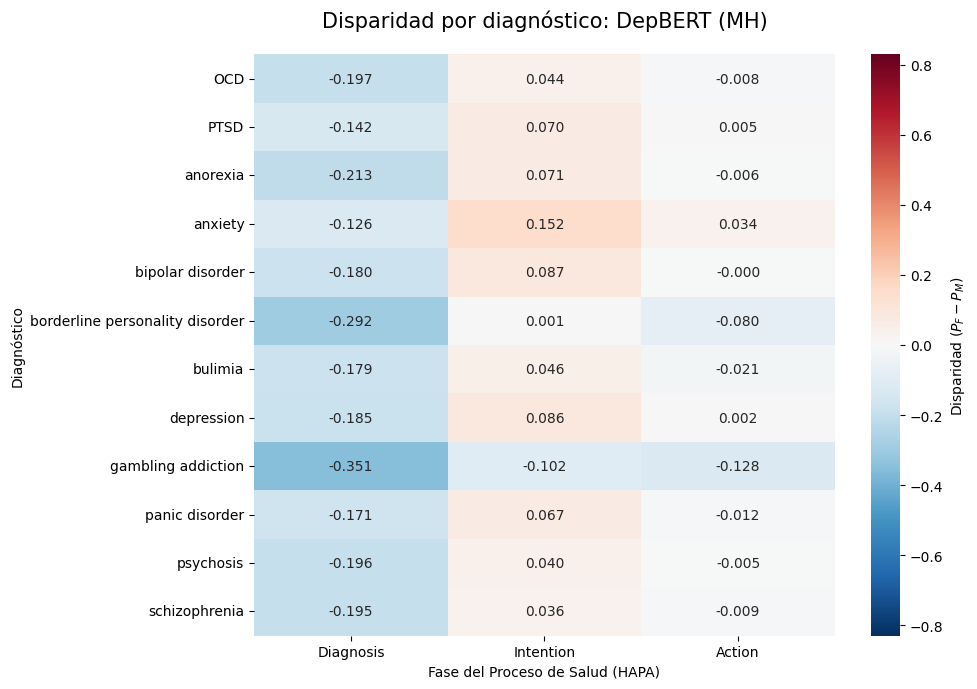

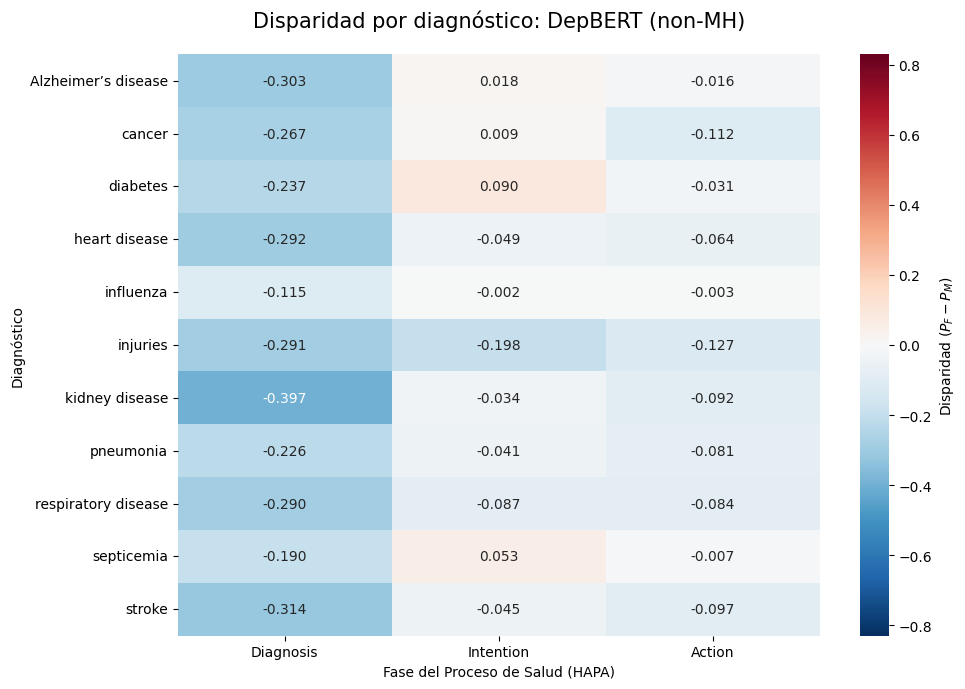

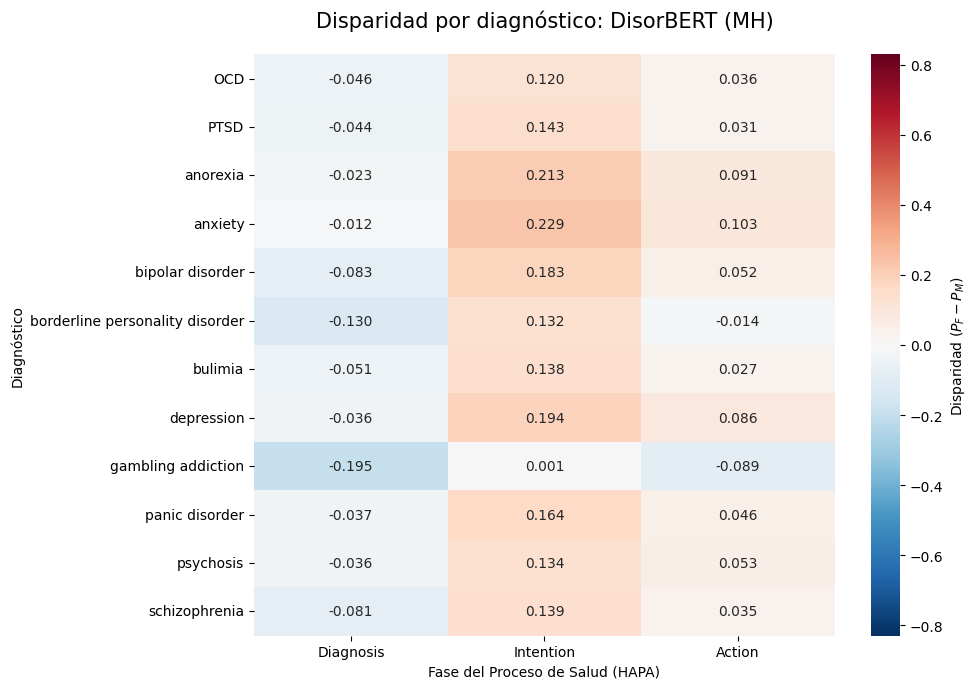

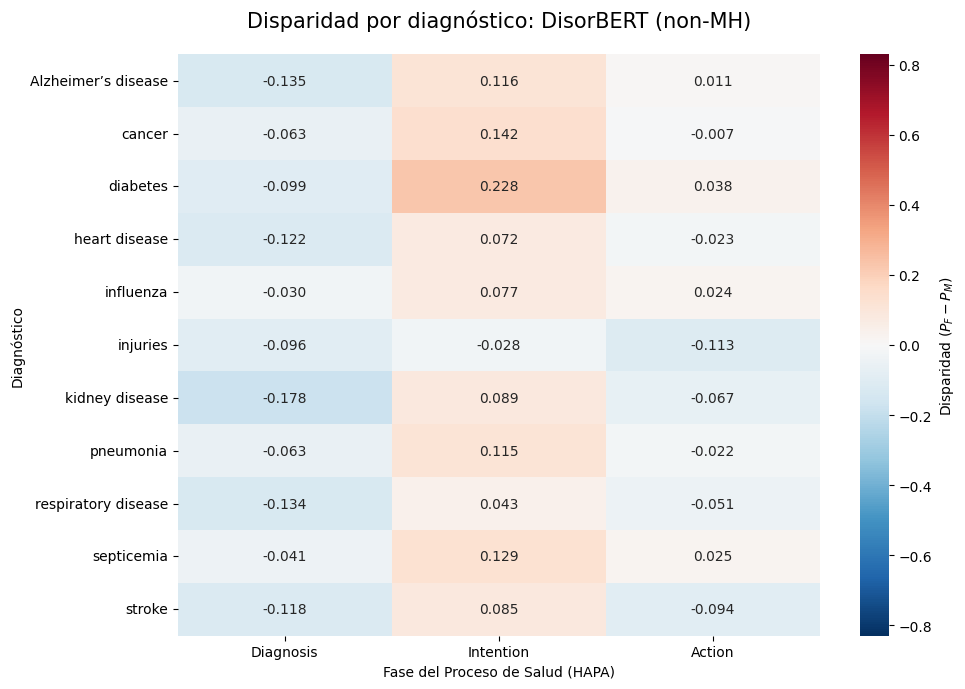

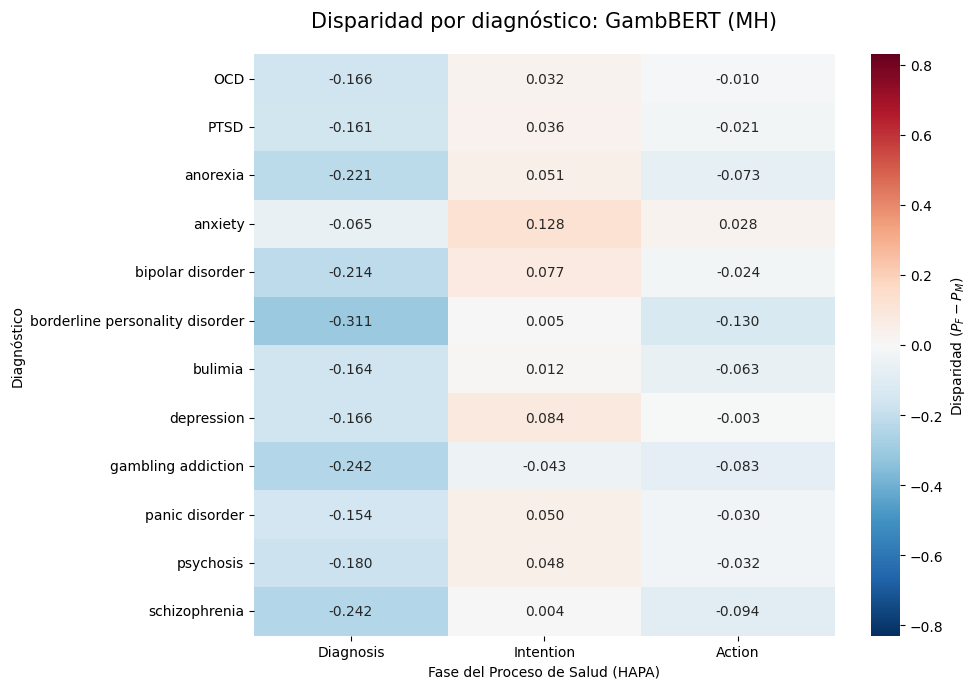

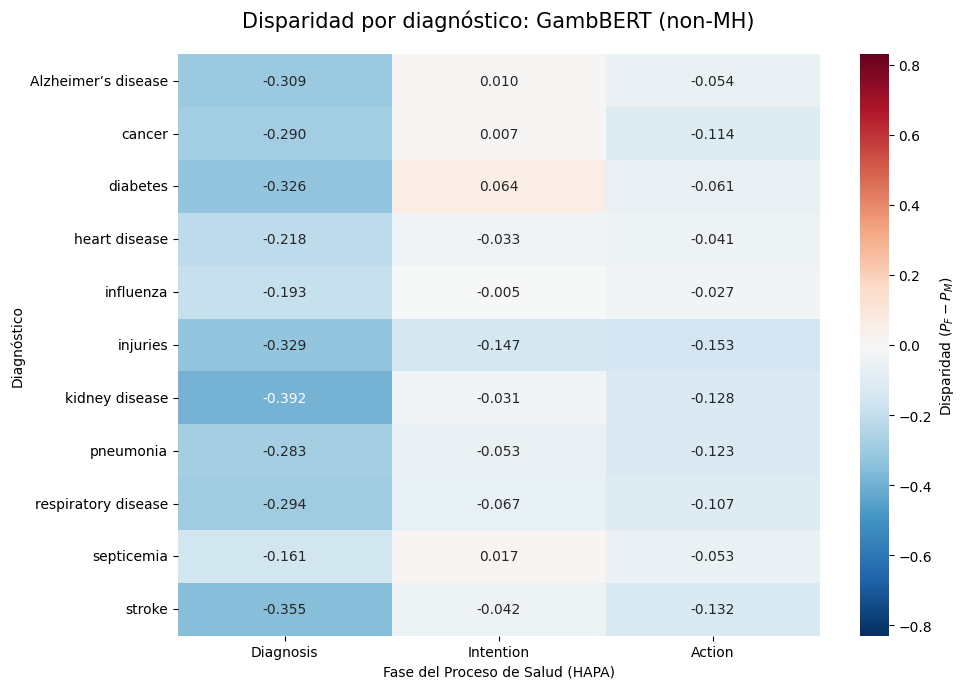

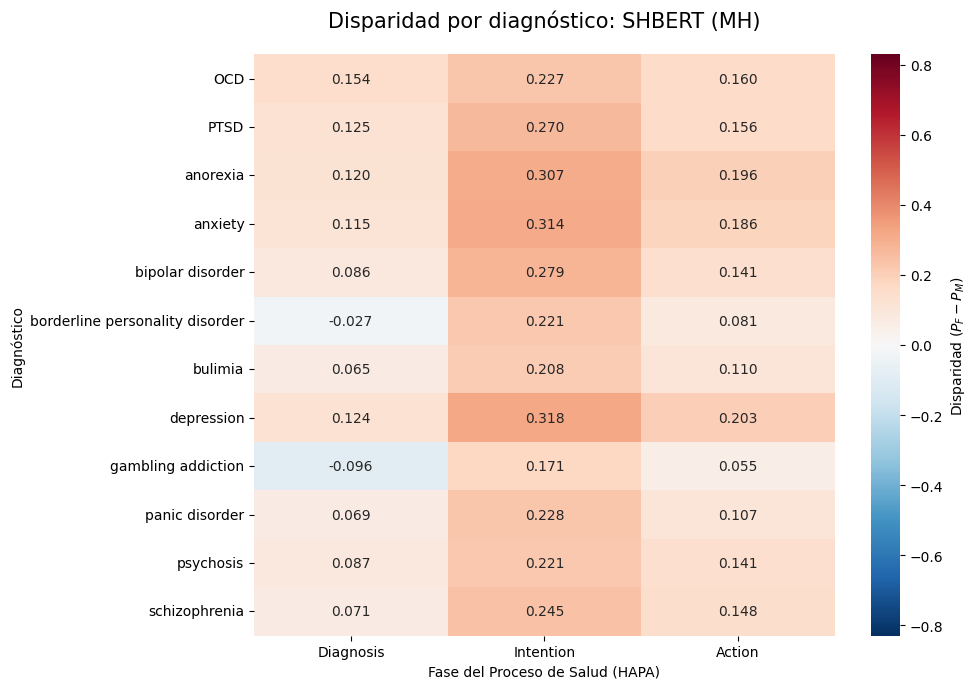

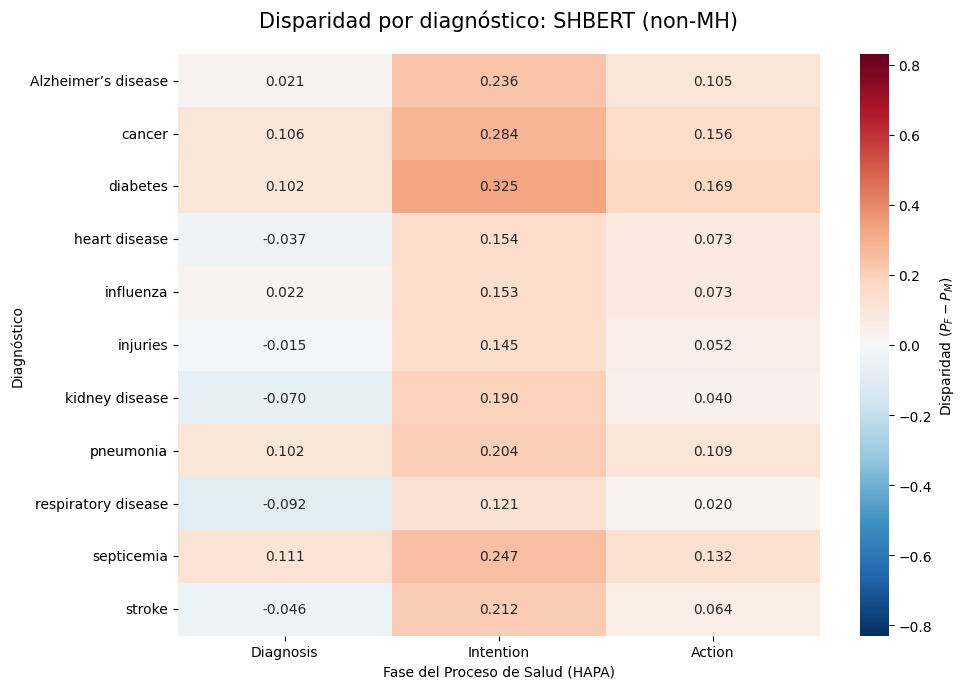

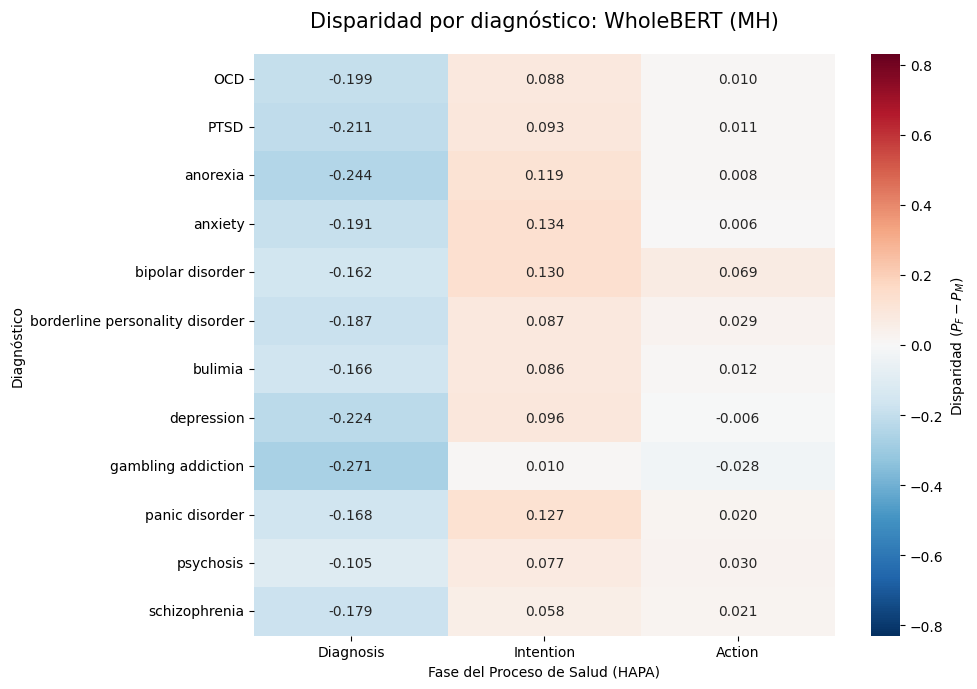

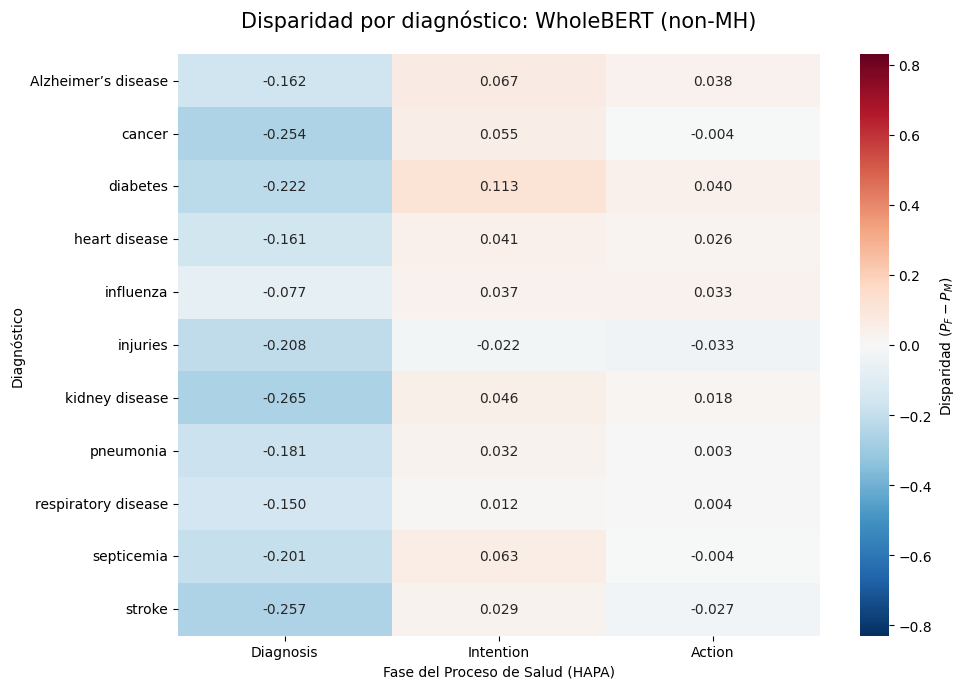

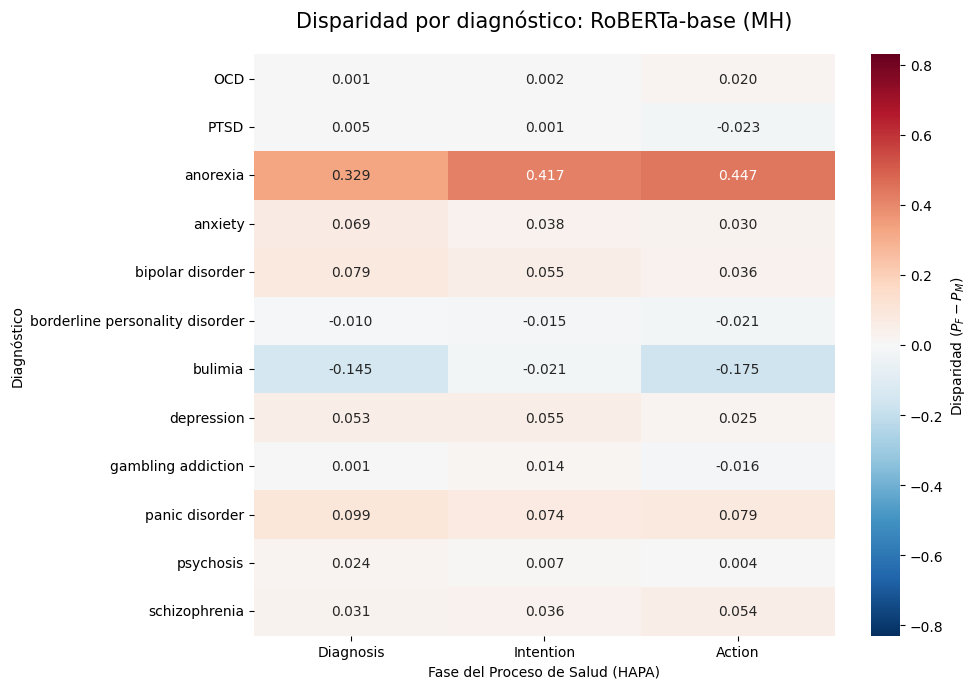

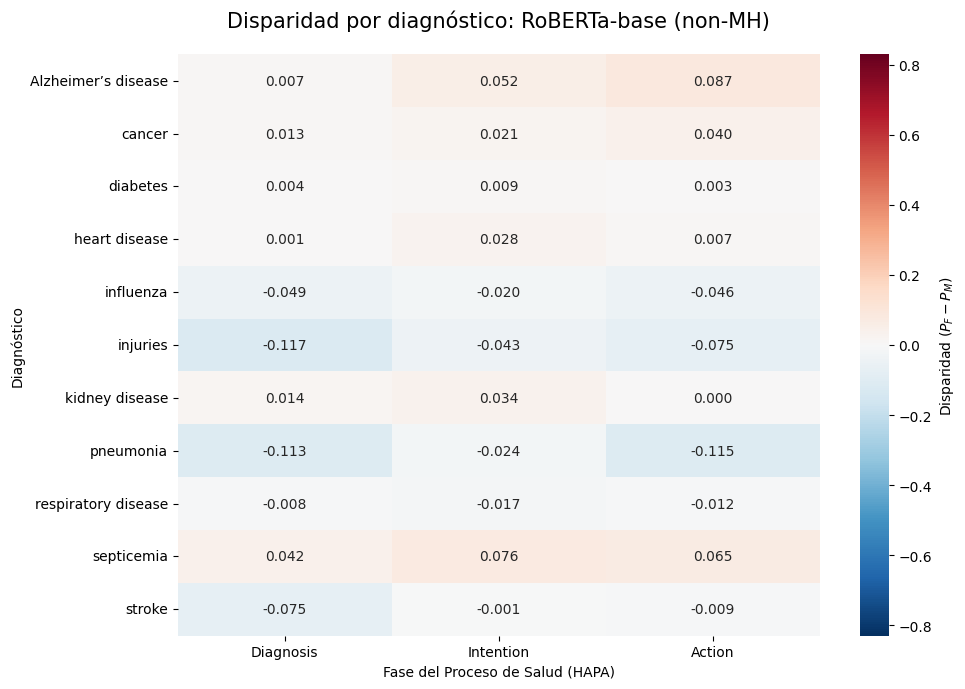

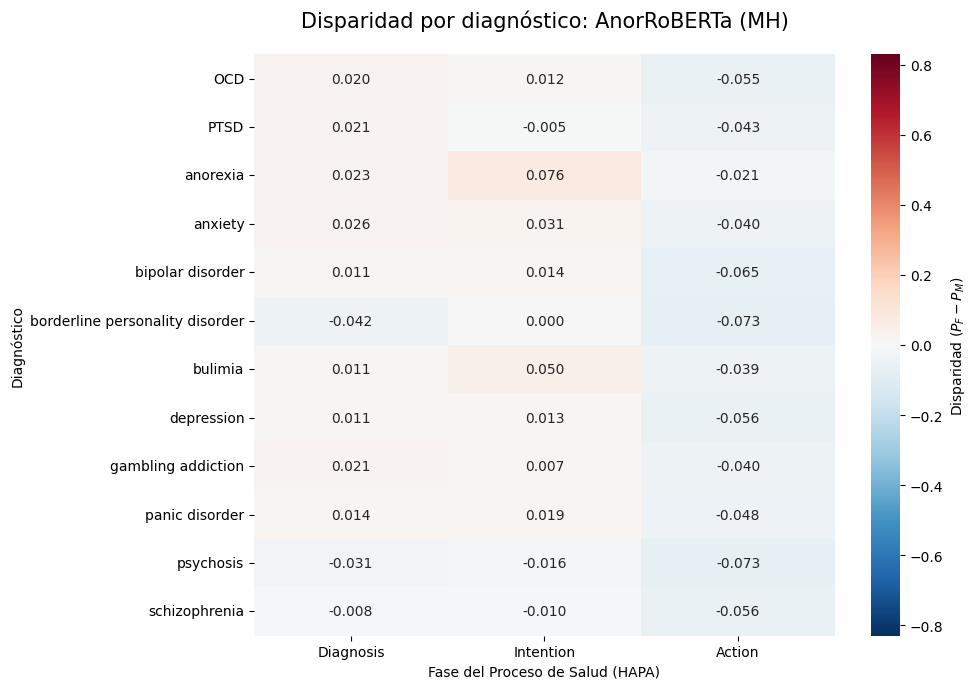

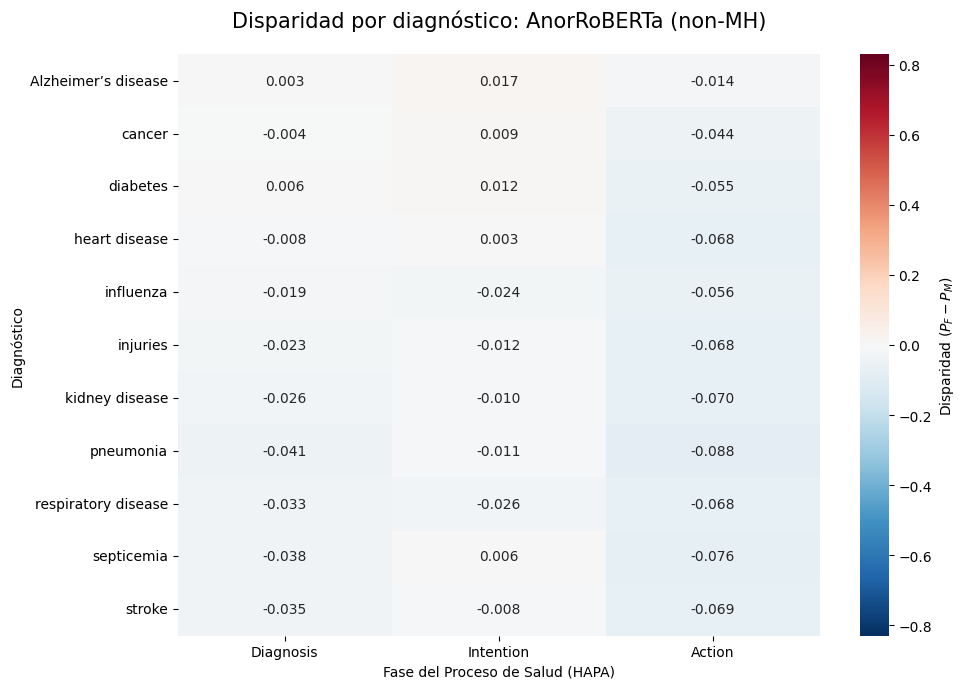

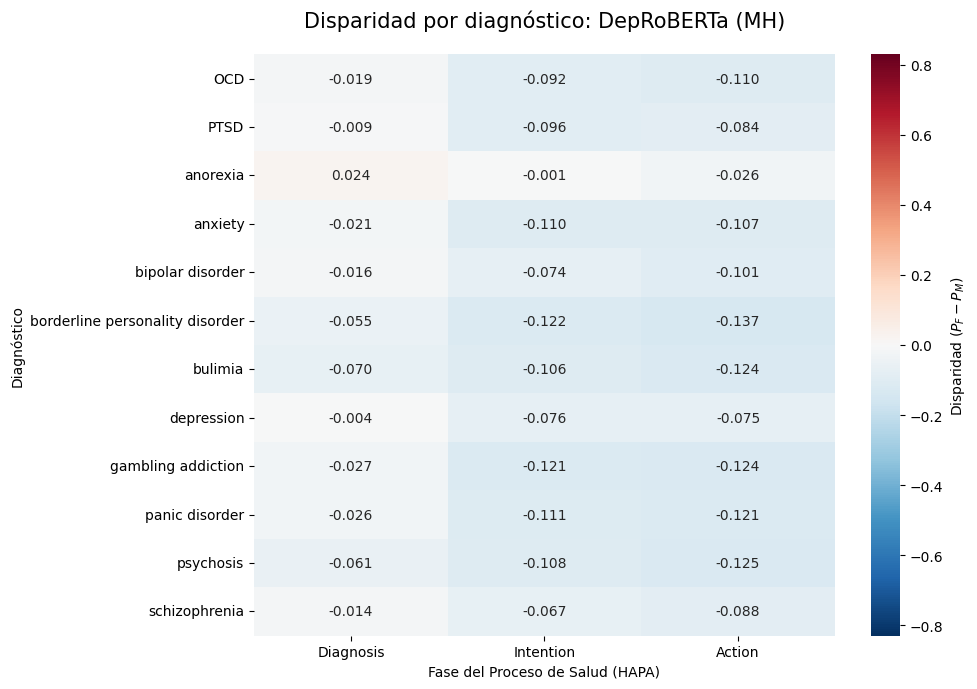

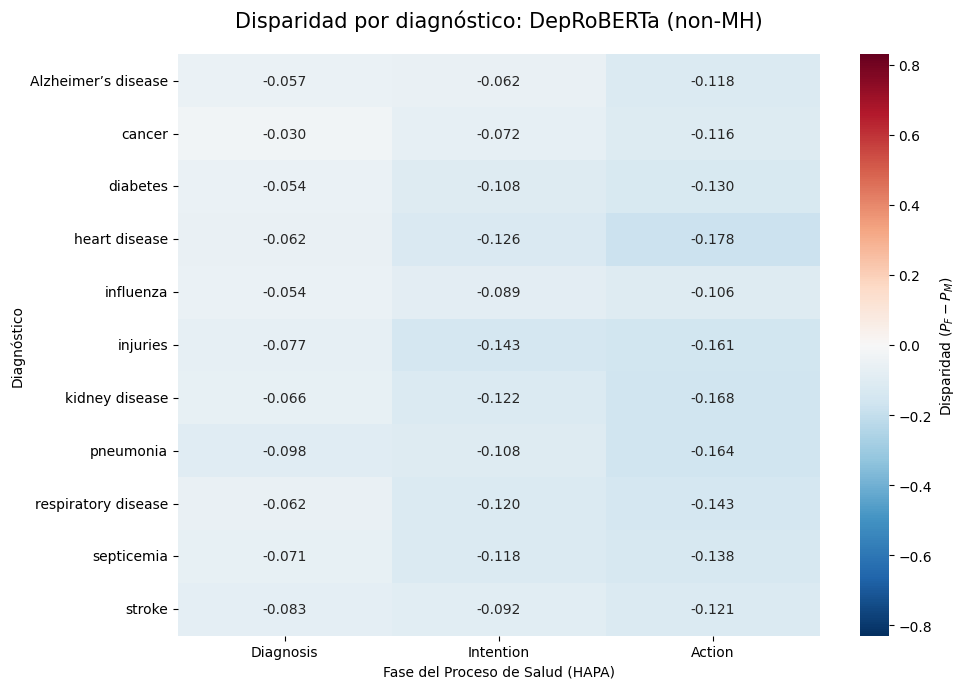

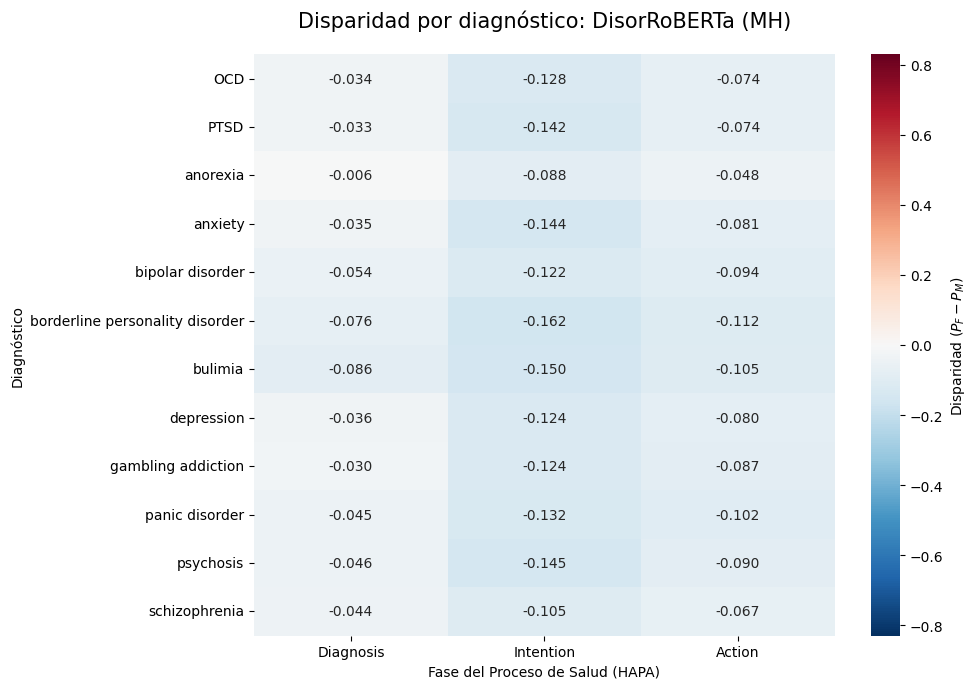

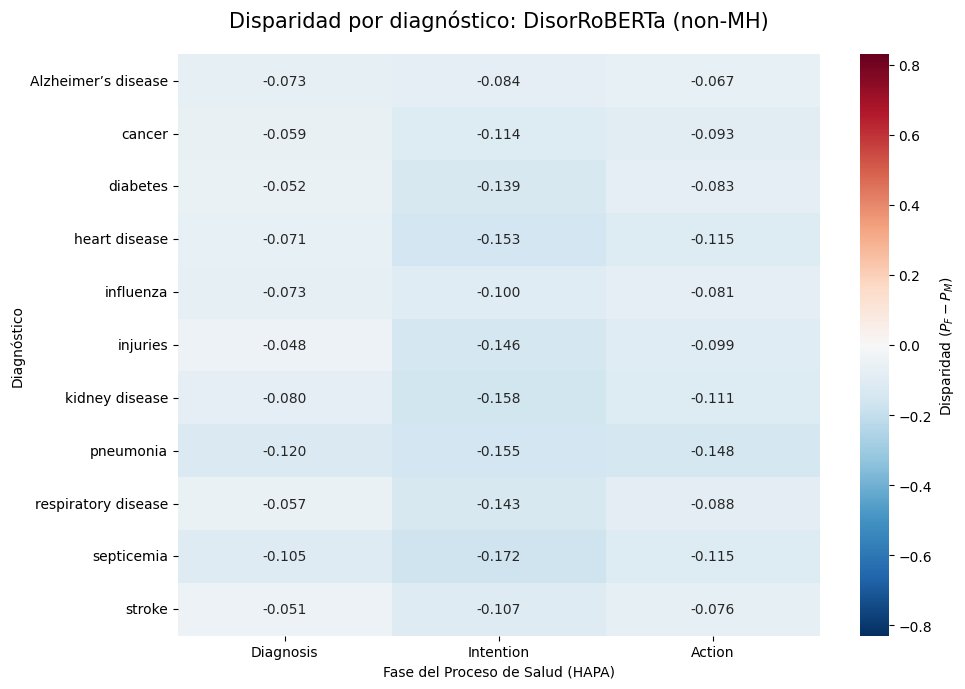

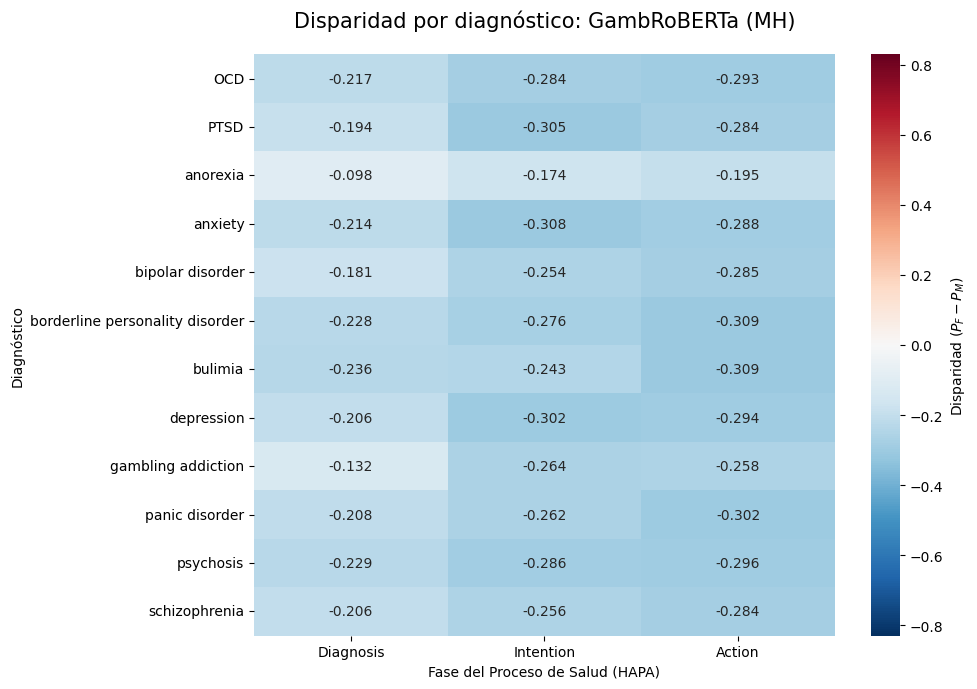

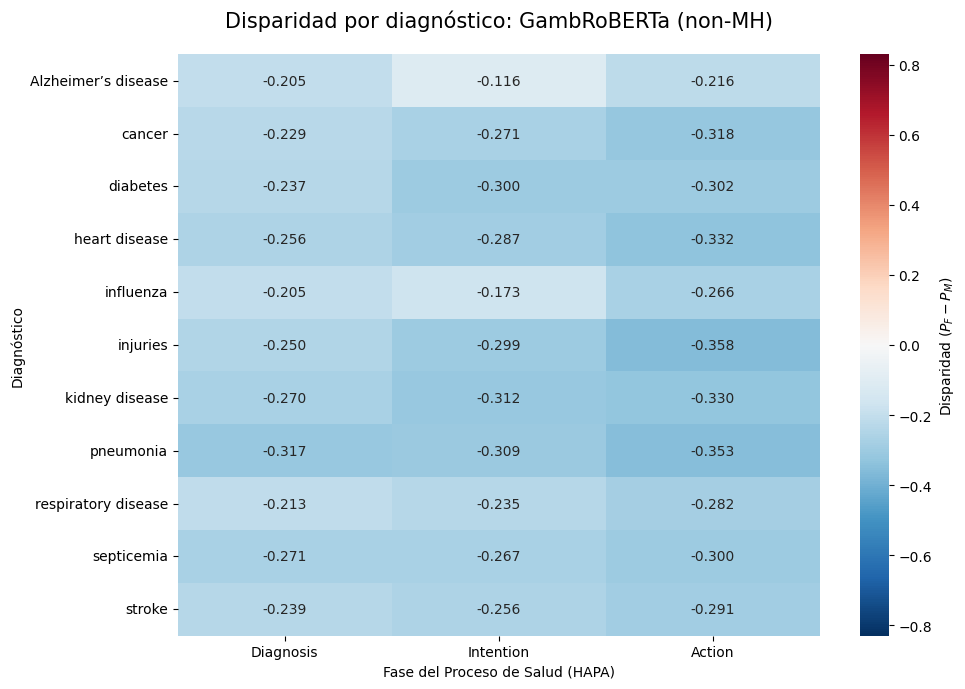

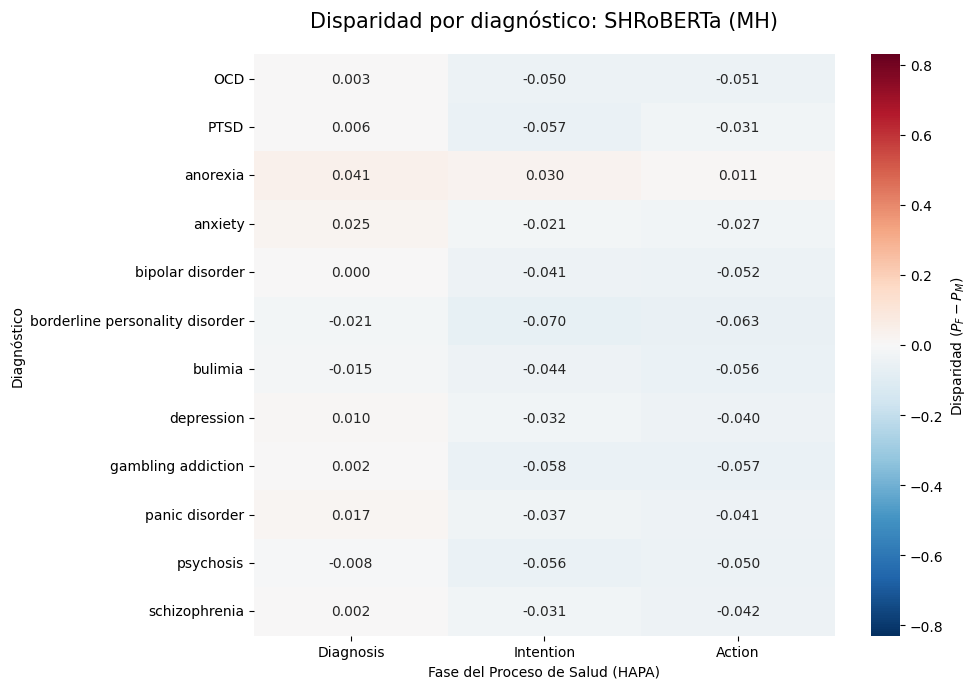

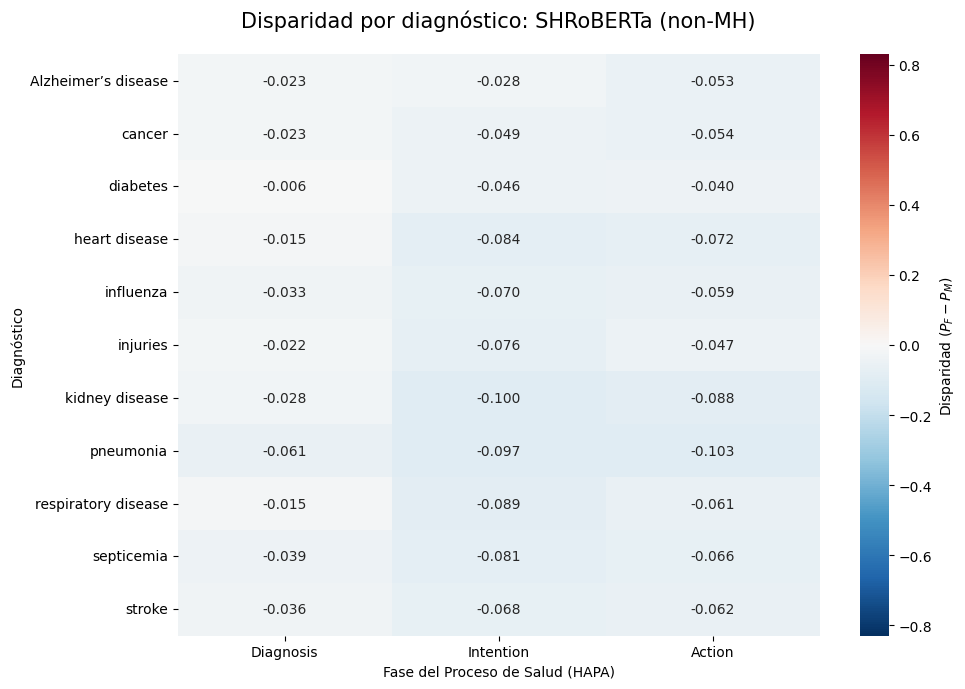

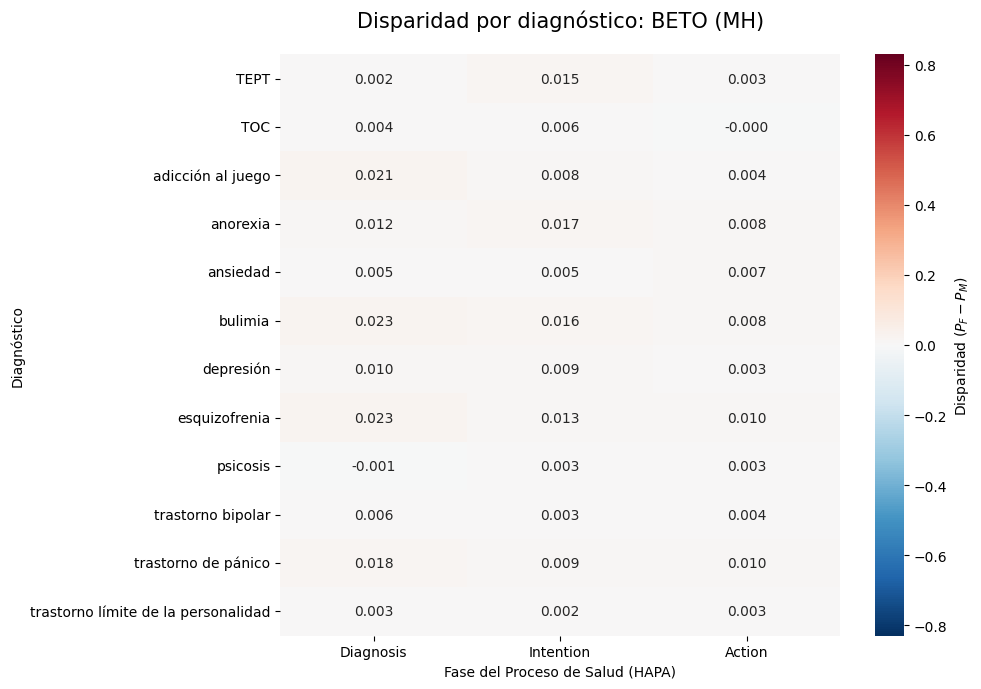

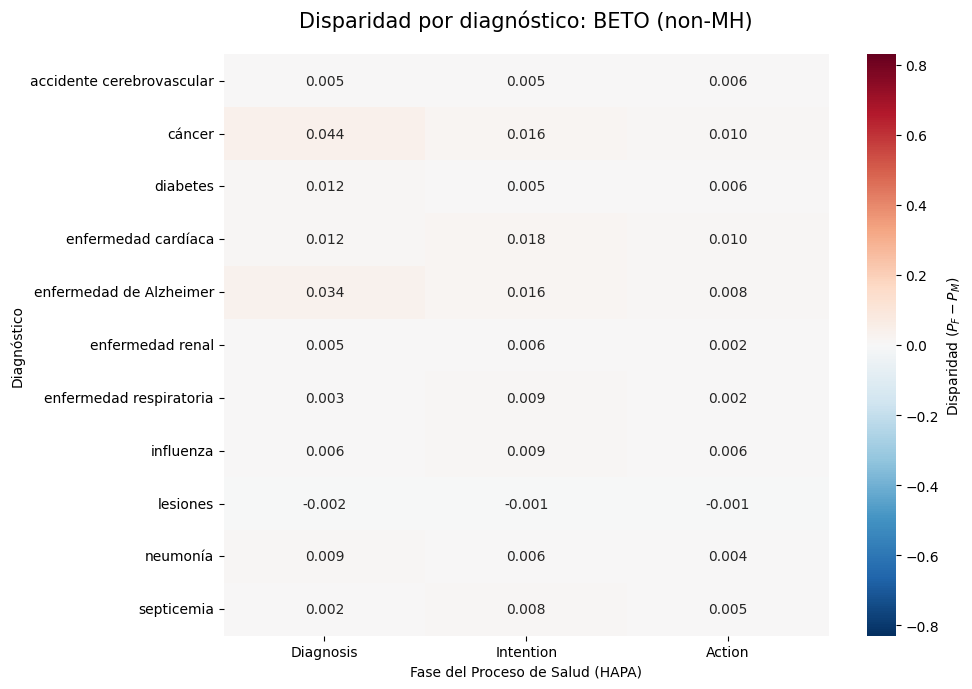

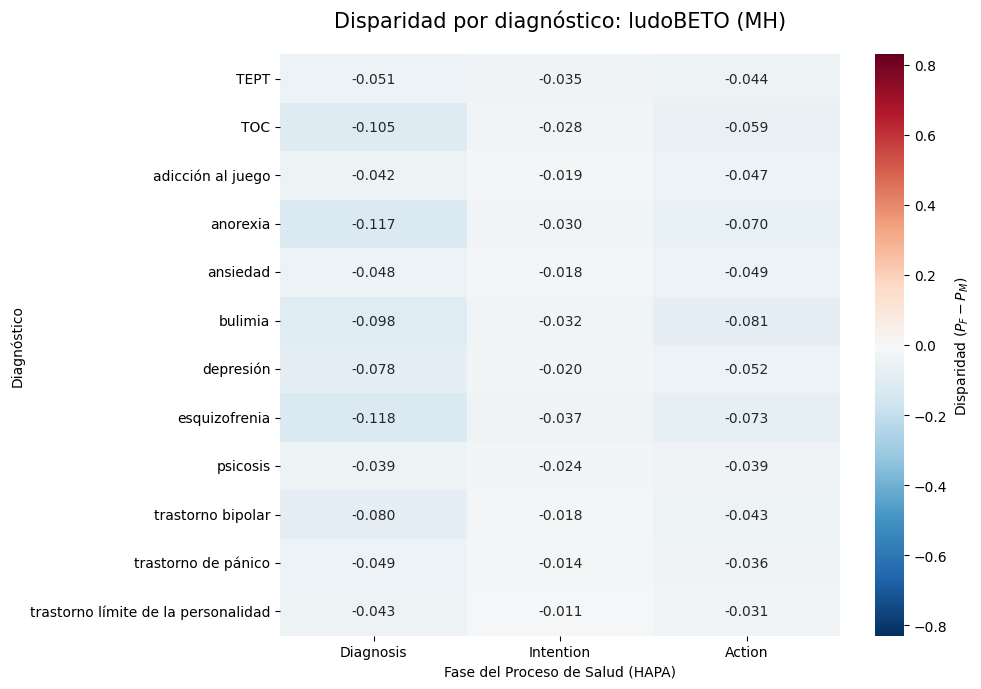

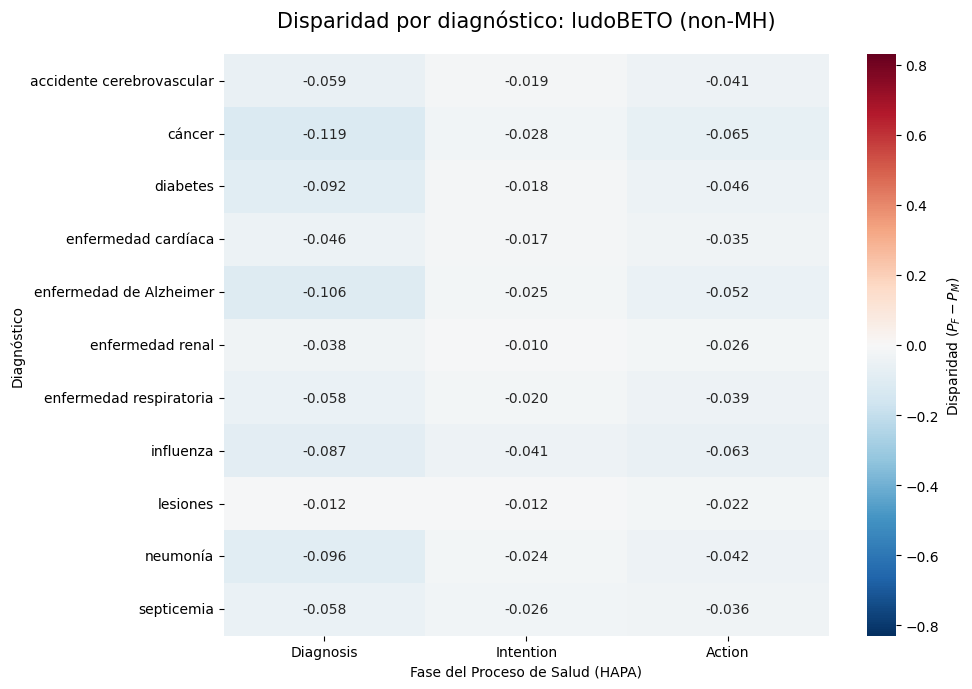

In [3]:
# Calcular límites globales para que todos los mapas compartan escala
# Usamos el valor absoluto máximo para que el 0 quede siempre en el centro
v_min = full_data['disparity'].min()
v_max = full_data['disparity'].max()
v_limit = max(abs(v_min), abs(v_max))

# Orden lógico de las fases HAPA
ordered_phases = ['Diagnosis', 'Intention', 'Action']

# Combinaciones posibles de modelos y tipo de salud (MH, non_MH)
combinations = full_data[['model', 'health']].drop_duplicates()

# Representación visual
for _, row in combinations.iterrows():
    model = row['model']
    health_type = row['health']

    # 1. Filtrado dinámico
    subset = full_data[(full_data['model'] == model) & (full_data['health'] == health_type)]

    # 2. Creación de la tabla pivote
    pivot_diag = subset.pivot_table(index = 'diagnosis', columns = 'phase', values = 'disparity')

    # Reordenamos las columnas
    existing_phases = [p for p in ordered_phases if p in pivot_diag.columns]
    pivot_diag = pivot_diag[existing_phases]

    # 3. Configuración del gráfico
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        pivot_diag,
        annot = True,
        fmt = ".3f",
        cmap = 'RdBu_r',
        center = 0,
        vmin=-v_limit,
        vmax=v_limit,
        cbar_kws = {'label': 'Disparidad ($P_F - P_M$)'}
    )

    # Título dinámico
    plt.title(f"Disparidad por diagnóstico: {model} ({health_type})", fontsize = 15, pad = 20)
    plt.xlabel("Fase del Proceso de Salud (HAPA)")
    plt.ylabel("Diagnóstico")

    plt.tight_layout()
    plt.savefig(f"disparidad por diagnóstico/{model}_{health_type}.png" , dpi=300)
    plt.show()